# 01 Â· Exploratory analysis of the US Treasury yield curve

Daily constant-maturity Treasury yields from FRED (1M to 30Y), cleaned and cached by `yieldcurve.data`. This notebook looks at:

1. which maturities are available, and since when;
2. the shape of the curve on a few key dates;
3. the full history in one heatmap.

The figures come from `yieldcurve.plots`, so the dashboard can reuse them. The data loads from `data/us_treasury_yields.parquet`; if that cache is missing it is built from FRED on the first run (`python -m yieldcurve.data` refreshes it).

In [1]:
import pandas as pd
import plotly.io as pio

from yieldcurve import plots
from yieldcurve.data import curve_on, load_us_yields

# Interactive figures in Jupyter / VS Code, plus a static PNG copy so the
# notebook still shows its charts on GitHub.
pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].width = 900
pio.renderers["png"].height = 540

In [2]:
yields = load_us_yields()
yields.tail()

,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,,,,,
2026-09-18,3.97,4.14,4.24,4.44,4.76,4.83,4.86,4.93,5.01,5.38,5.34
2026-09-21,3.96,4.17,4.27,4.45,4.76,4.82,4.83,4.89,4.96,5.33,5.29
2026-09-22,3.97,4.16,4.26,4.43,4.71,4.81,4.83,4.89,4.96,5.33,5.29
2026-09-23,3.99,4.19,4.31,4.49,4.85,4.97,4.99,5.05,5.11,5.45,5.40
2026-09-24,4.01,4.24,4.34,4.51,4.87,4.99,5.03,5.10,5.18,5.53,5.47


## Data coverage

Not every maturity exists over the whole history, so the first valid date per column matters for anything that needs the full curve.

In [3]:
coverage = pd.DataFrame(
    {
        "first_date": yields.apply(lambda s: s.first_valid_index().date()),
        "last_date": yields.apply(lambda s: s.last_valid_index().date()),
        "observations": yields.count(),
    }
)
coverage

,first_date,last_date,observations
1M,2001-07-31,2026-09-24,6290
3M,1981-09-01,2026-09-24,11267
6M,1981-09-01,2026-09-24,11267
1Y,1962-01-02,2026-09-24,16168
2Y,1976-06-01,2026-09-24,12576
3Y,1962-01-02,2026-09-24,16168
5Y,1962-01-02,2026-09-24,16168
7Y,1969-07-01,2026-09-24,14298
10Y,1962-01-02,2026-09-24,16168
20Y,1962-01-02,2026-09-24,14479


- The 1Y, 3Y, 5Y, 10Y and 20Y series start in 1962. The 30Y starts in 1977, and the 3M and 6M in September 1981.
- The 1M only starts on **2001-07-31**, so the full 11-point curve is available from then on. Later phases (Nelson-Siegel, PCA) work on that window.
- The 20Y has a structural gap in 1987â€“1993, when it was not issued. The pipeline leaves it missing instead of filling it.

## The curve on key dates

Four regimes, plus the latest curve for reference. Two of the dates are found from the data rather than typed in:

- **COVID low:** the day the 10Y hit its 2020 minimum.
- **2022 hiking peak:** the day the 2Y reached its 2022 high, i.e. when the market priced the most tightening that year.

Dates that fall on a weekend or holiday roll back to the previous trading day; the legend shows the date actually used.

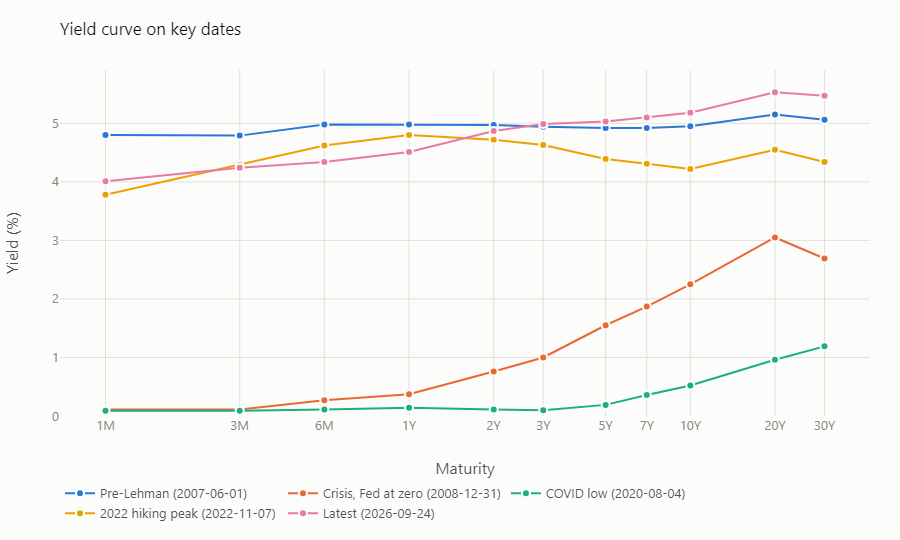

In [4]:
covid_low = yields.loc["2020", "10Y"].idxmin()
hiking_peak = yields.loc["2022", "2Y"].idxmax()

KEY_DATES = {
    "Pre-Lehman": "2007-06-01",
    "Crisis, Fed at zero": "2008-12-31",
    "COVID low": covid_low,
    "2022 hiking peak": hiking_peak,
    "Latest": yields.index[-1],
}
plots.curve_snapshots(yields, KEY_DATES)

In [5]:
curves = {label: curve_on(yields, date) for label, date in KEY_DATES.items()}
snapshots = pd.DataFrame(curves).T.reindex(columns=yields.columns).round(2)
snapshots.insert(0, "date", [curve.name.date() for curve in curves.values()])
snapshots

,date,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Pre-Lehman,2007-06-01,4.80,4.79,4.98,4.98,4.97,4.94,4.92,4.92,4.95,5.15,5.06
"Crisis, Fed at zero",2008-12-31,0.11,0.11,0.27,0.37,0.76,1.00,1.55,1.87,2.25,3.05,2.69
COVID low,2020-08-04,0.09,0.09,0.11,0.14,0.11,0.10,0.19,0.36,0.52,0.96,1.19
2022 hiking peak,2022-11-07,3.78,4.29,4.62,4.80,4.72,4.63,4.39,4.31,4.22,4.55,4.34
Latest,2026-09-24,4.01,4.24,4.34,4.51,4.87,4.99,5.03,5.10,5.18,5.53,5.47


What the shapes say:

- **Pre-Lehman (June 2007): flat.** Every maturity sat between 4.8% and 5.2%. The 10Y was only 16 bp above the 3M bill, which leaves little term premium just before the crisis.
- **End of 2008: steep.** The Fed cut to 0â€“0.25% on 16 December 2008. Bills yielded about 0.1% while the 10Y stayed at 2.25%. This is the classic easing-cycle shape: the front end is pinned by policy, and the long end prices an eventual recovery.
- **COVID low (2020-08-04): the whole curve near zero.** The 10Y closed at a record 0.52%, and only the 20Y and 30Y were anywhere near 1%.
- **2022 hiking peak (2022-11-07): inverted.** The curve peaks at the 1Y (4.80%), and the 10Y is 58 bp lower (4.22%). The market expected rates to be cut again after the hiking cycle.
- **Latest (cache through 2026-09-24): upward sloping again**, from 4.0% at the 1M to about 5.5% at the 20Y and 30Y.

One recurring detail: **the 20Y often yields more than the 30Y**, which bends the long end of the curve. A smooth curve model cannot produce that kink, so it is worth checking as a persistent residual in the Nelson-Siegel fits (Phase 3).

## Full history

Monthly averages of every maturity since 1962. Darker means higher yields; blank cells are maturities that were not issued at the time.

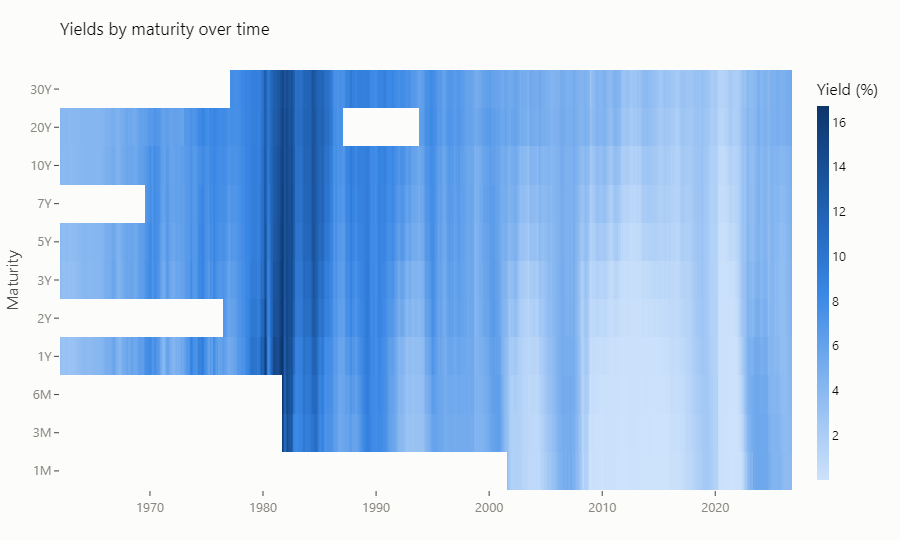

In [6]:
plots.yield_heatmap(yields)

- **The Volcker peak.** Short rates topped 17% in September 1981 (3M 17.01% on 1981-09-01, 1Y 17.31% on 1981-09-03), and the 10Y peaked at 15.84% on 1981-09-30.
- **Four decades of decline.** Yields at every maturity fell, with cycles along the way, from 1981 to 2020.
- **Two zero-rate periods.** The 3M bill stayed below 0.25% almost continuously from late 2008 to December 2015, and again from April 2020 to February 2022. These are the pale bands at the short end. The long end stayed higher, so the curve was steep in both periods.
- **The 2022 re-pricing.** The monthly average 3M rose from 0.15% in January 2022 to 4.36% in December. The front end overtook the long end within the year, which is the inversion seen in the snapshot above.